# PATHQ — Week 1: Environment Setup & Data Pipeline
**Quantum Digital Pathology for Whole Slide Image Analysis**

---
### What this notebook does
1. Verifies your entire environment is working
2. Downloads PathMNIST and PatchCamelyon
3. Loads and explores CAMELYON16 WSI slides
4. Extracts tissue patches with Otsu filtering
5. Applies Macenko stain normalisation
6. Saves patches to disk ready for Week 2

**Run every cell top to bottom. Fix any errors before moving on.**

---
## Cell 1 — Verify GPU and all imports

In [1]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── GPU Check ──────────────────────────────────────────────────────────────
print('='*60)
print('PATHQ ENVIRONMENT CHECK')
print('='*60)
print(f'Python:      {sys.version.split()[0]}')
print(f'PyTorch:     {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU name:    {torch.cuda.get_device_name(0)}')
    print(f'VRAM total:  {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    DEVICE = torch.device('cuda')
else:
    print('WARNING: No GPU detected — training will be slow')
    DEVICE = torch.device('cpu')

print(f'Device:      {DEVICE}')
print('='*60)

PATHQ ENVIRONMENT CHECK
Python:      3.10.20
PyTorch:     2.11.0+cu128
CUDA available: True
GPU name:    NVIDIA GeForce RTX 5060 Laptop GPU
VRAM total:  8.1 GB
Device:      cuda


In [ ]:
# ── Import all PATHQ dependencies ──────────────────────────────────────────
import_status = {}

try:
    import torch_geometric
    import_status['PyTorch Geometric'] = torch_geometric.__version__
except ImportError as e:
    import_status['PyTorch Geometric'] = f'MISSING: {e}'

try:
    import pennylane as qml
    import_status['PennyLane'] = qml.__version__
except ImportError as e:
    import_status['PennyLane'] = f'MISSING: {e}'

try:
    import qiskit
    import_status['Qiskit'] = qiskit.__version__
except ImportError as e:
    import_status['Qiskit'] = f'MISSING: {e}'

try:
    import openslide
    import_status['OpenSlide'] = openslide.__version__
except ImportError as e:
    import_status['OpenSlide'] = f'MISSING — run: conda install -c conda-forge openslide'

try:
    import torchstain
    import_status['torchstain'] = 'OK'
except ImportError as e:
    import_status['torchstain'] = f'MISSING: {e}'

try:
    import timm
    import_status['timm'] = timm.__version__
except ImportError as e:
    import_status['timm'] = f'MISSING: {e}'

try:
    import medmnist
    import_status['medmnist'] = medmnist.__version__
except ImportError as e:
    import_status['medmnist'] = f'MISSING: {e}'

try:
    import wandb
    import_status['wandb'] = wandb.__version__
except ImportError as e:
    import_status['wandb'] = f'MISSING: {e}'

try:
    from sklearn.metrics import roc_auc_score
    import_status['scikit-learn'] = 'OK'
except ImportError as e:
    import_status['scikit-learn'] = f'MISSING: {e}'

print('\nDEPENDENCY STATUS:')
all_ok = True
for lib, status in import_status.items():
    icon = 'OK' if 'MISSING' not in str(status) else 'FAIL'
    print(f'  [{icon}]  {lib}: {status}')
    if 'MISSING' in str(status):
        all_ok = False

print()
if all_ok:
    print('All dependencies OK — ready to build PATHQ!')
else:
    print('Fix MISSING dependencies before continuing.')

/home/kabilash/miniconda3/envs/pathq/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



DEPENDENCY STATUS:
  [OK]  PyTorch Geometric: 2.7.0
  [OK]  PennyLane: 0.42.3
  [OK]  Qiskit: 1.2.4
  [OK]  OpenSlide: 1.4.3
  [OK]  torchstain: OK
  [OK]  timm: 1.0.26
  [OK]  medmnist: 3.0.2
  [OK]  wandb: 0.25.1
  [OK]  scikit-learn: OK

All dependencies OK — ready to build PATHQ!


---
## Cell 2 — Project configuration (edit paths here)

In [3]:
# ── PATHQ Configuration ────────────────────────────────────────────────────
# EDIT THESE PATHS to match your machine

class Config:
    # ── Paths ────────────────────────────────────────────────────────
    PROJECT_ROOT    = Path('./').parent          # pathq_project/
    DATA_DIR        = Path('./data')             # where datasets go
    PATCHES_DIR     = Path('./data/patches')     # extracted patches
    FEATURES_DIR    = Path('./data/features')    # ResNet .pt files (Week 2)
    CHECKPOINTS_DIR = Path('./checkpoints')      # model saves
    OUTPUTS_DIR     = Path('./outputs')          # figures, results
    
    # CAMELYON16 slides — update this to wherever you saved them
    CAMELYON16_DIR  = Path('./data/camelyon16')  # put .tif slides here
    
    # ── Preprocessing ────────────────────────────────────────────────
    PATCH_SIZE      = 256       # pixels per patch (standard)
    MAGNIFICATION   = 20        # 20x magnification level
    LEVEL           = 1         # pyramid level (0=highest res, use 1 for speed)
    BACKGROUND_THR  = 0.85      # Otsu: reject if > 85% background
    KNN_K           = 8         # K neighbours for patch graph
    
    # ── Model ────────────────────────────────────────────────────────
    FEATURE_DIM     = 512       # ResNet-50 output dimension
    VQC_INPUT_DIM   = 8         # projected dim before amplitude encoding
    N_QUBITS        = 3         # qubits (2^3 = 8 amplitudes = VQC_INPUT_DIM)
    VQC_LAYERS      = 2         # VQC circuit depth
    GNN_HIDDEN      = 256       # GCN hidden dimension
    
    # ── Training ────────────────────────────────────────────────────
    BATCH_SIZE      = 4         # slides per batch (safe for 8GB VRAM)
    LR              = 1e-4      # learning rate
    EPOCHS          = 50        # training epochs
    SEED            = 42
    
    DEVICE          = DEVICE

cfg = Config()

# Create all directories
for d in [cfg.DATA_DIR, cfg.PATCHES_DIR, cfg.FEATURES_DIR,
          cfg.CHECKPOINTS_DIR, cfg.OUTPUTS_DIR, cfg.CAMELYON16_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Set random seeds for reproducibility
torch.manual_seed(cfg.SEED)
np.random.seed(cfg.SEED)

print('Config loaded:')
print(f'  Device:      {cfg.DEVICE}')
print(f'  Patch size:  {cfg.PATCH_SIZE}px')
print(f'  N qubits:    {cfg.N_QUBITS} (encodes {2**cfg.N_QUBITS} values)')
print(f'  Data dir:    {cfg.DATA_DIR.resolve()}')
print('Directories created.')

Config loaded:
  Device:      cuda
  Patch size:  256px
  N qubits:    3 (encodes 8 values)
  Data dir:    /home/kabilash/PATHQ--Quantum-Digital-Pathology-for-Whole-Slide-Image-Analysis-DMI-/notebooks/data
Directories created.


In [2]:
from datasets import load_dataset
import os

cache = os.path.expanduser("~/.cache/huggingface/datasets")
print("Cache folder:", cache)

print("\nLoading PatchCamelyon...")
ds = load_dataset("1aurent/PatchCamelyon")

print("\nSTATUS: DOWNLOADED")

if "train" in ds:
    print(f"Train: {len(ds['train']):,} samples")

if "validation" in ds:
    print(f"Val: {len(ds['validation']):,} samples")
else:
    print("Val: Not available")

if "test" in ds:
    print(f"Test: {len(ds['test']):,} samples")

# Sample check
img = ds["train"][0]["image"]
lbl = ds["train"][0]["label"]

print(f"\nSample image size: {img.size}")
print(f"Sample label: {lbl} ({'tumour' if lbl == 1 else 'normal'})")

Cache folder: /home/kabilash/.cache/huggingface/datasets

Loading PatchCamelyon...

STATUS: DOWNLOADED
Train: 262,144 samples
Val: Not available
Test: 32,768 samples

Sample image size: (96, 96)
Sample label: False (normal)


---
## Cell 3 — Download PathMNIST (instant)

100%|██████████| 206M/206M [01:07<00:00, 3.07MB/s] 


Train: 89,996 samples
Test:  7,180 samples
Classes: {'0': 'adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'}


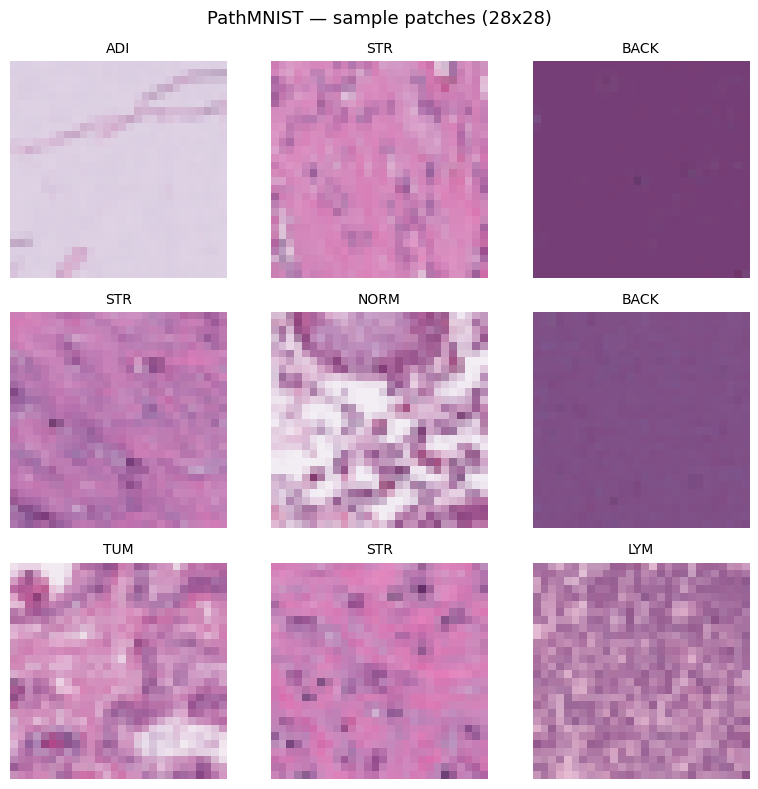

PathMNIST ready.


In [4]:
import medmnist
from medmnist import PathMNIST
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

print('Downloading PathMNIST...')

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

path_train = PathMNIST(split='train', transform=transform,
                        download=True, root=str(cfg.DATA_DIR))
path_test  = PathMNIST(split='test',  transform=transform,
                        download=True, root=str(cfg.DATA_DIR))

print(f'Train: {len(path_train):,} samples')
print(f'Test:  {len(path_test):,} samples')
print(f'Classes: {path_train.info["label"]}')

# Quick visualisation — 9 random patches
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
fig.suptitle('PathMNIST — sample patches (28x28)', fontsize=13)

class_names = ['ADI', 'BACK', 'DEB', 'LYM', 'MUC', 'MUS', 'NORM', 'STR', 'TUM']

for i, ax in enumerate(axes.flat):
    img, label = path_train[i * 1000]
    img_np = img.permute(1, 2, 0).numpy()
    img_np = (img_np * 0.5 + 0.5).clip(0, 1)
    ax.imshow(img_np)
    ax.set_title(class_names[label[0]], fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig(str(cfg.OUTPUTS_DIR / 'pathmnist_samples.png'), dpi=100, bbox_inches='tight')
plt.show()
print('PathMNIST ready.')

---
## Cell 4 — Download PatchCamelyon (7.5 GB — takes 10-30 min)

This is 7.5 GB — go grab a coffee.

Train: 235,929 samples
Valid: 26,215 samples
Test:  32,768 samples
Features: {'image': Image(mode=None, decode=True), 'label': Value('bool')}


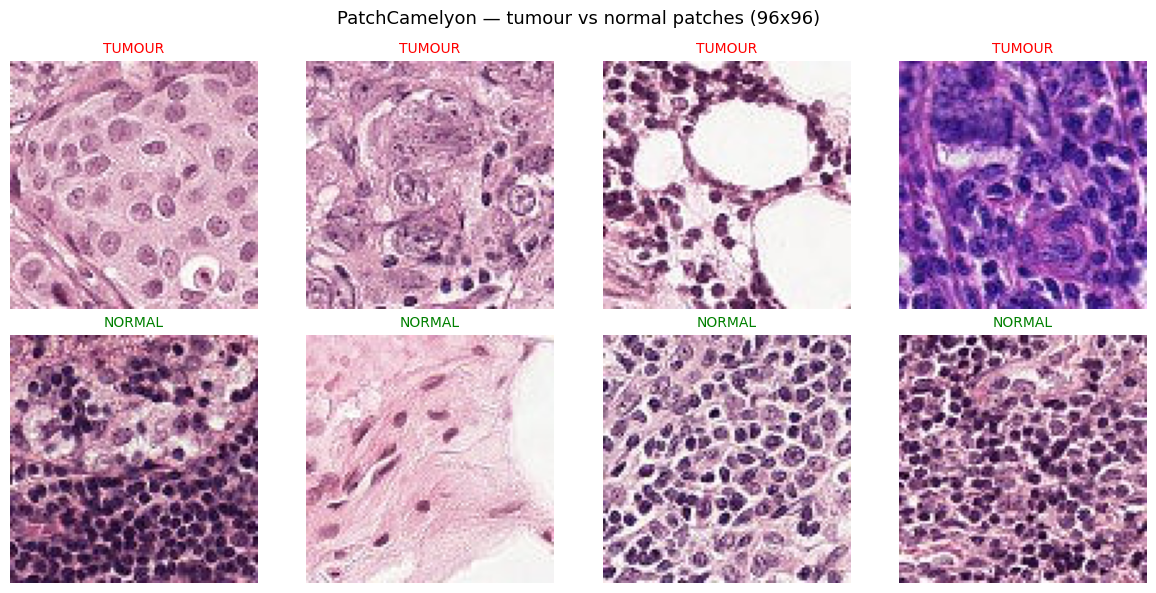

PatchCamelyon ready.


In [10]:
from datasets import load_dataset
import PIL.Image

print('Downloading PatchCamelyon...')
print('This is 7.5 GB — go grab a coffee.')
print()

# Downloads and caches automatically
pcam = load_dataset('1aurent/PatchCamelyon')

# Create validation split from training data (10% split)
train_val = pcam['train'].train_test_split(test_size=0.1, seed=42)
pcam['train'] = train_val['train']
pcam['validation'] = train_val['test']

print(f'Train: {len(pcam["train"]):,} samples')
print(f'Valid: {len(pcam["validation"]):,} samples')
print(f'Test:  {len(pcam["test"]):,} samples')
print(f'Features: {pcam["train"].features}')

# Quick visualisation
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle('PatchCamelyon — tumour vs normal patches (96x96)', fontsize=13)

tumour_samples  = [s for s in pcam['train'] if s['label'] == 1][:4]
normal_samples  = [s for s in pcam['train'] if s['label'] == 0][:4]

for i, (ax, sample) in enumerate(zip(axes[0], tumour_samples)):
    ax.imshow(sample['image'])
    ax.set_title(f'TUMOUR', color='red', fontsize=10)
    ax.axis('off')

for i, (ax, sample) in enumerate(zip(axes[1], normal_samples)):
    ax.imshow(sample['image'])
    ax.set_title(f'NORMAL', color='green', fontsize=10)
    ax.axis('off')
    

plt.tight_layout()
plt.savefig(str(cfg.OUTPUTS_DIR / 'pcam_samples.png'), dpi=100, bbox_inches='tight')
plt.show()
print('PatchCamelyon ready.')

---
## Cell 5 — CAMELYON16 WSI Explorer

> **Before running:** Place at least 1 CAMELYON16 .tif slide in `./data/camelyon16/`
> Download from: https://camelyon16.grand-challenge.org (free registration)
> Start with `tumor_001.tif` from the training set.

Found 220 slides:
  normal_001.tif
  normal_002.tif
  normal_003.tif
  normal_004.tif
  normal_005.tif
  normal_006.tif
  normal_007.tif
  normal_008.tif
  normal_009.tif
  normal_010.tif
  ... and 210 more

Slide: normal_001.tif
Dimensions (level 0): 97,792 x 221,184 px
Number of levels:     10
Level dimensions:
  Level 0: 97,792 x 221,184 px (downsample 1.0x)
  Level 1: 48,896 x 110,592 px (downsample 2.0x)
  Level 2: 24,448 x 55,296 px (downsample 4.0x)
  Level 3: 12,224 x 27,648 px (downsample 8.0x)
  Level 4: 6,112 x 13,824 px (downsample 16.0x)
  Level 5: 3,056 x 6,912 px (downsample 32.0x)
  Level 6: 1,528 x 3,456 px (downsample 64.0x)
  Level 7: 764 x 1,728 px (downsample 128.0x)
  Level 8: 382 x 864 px (downsample 256.0x)
  Level 9: 191 x 432 px (downsample 512.0x)


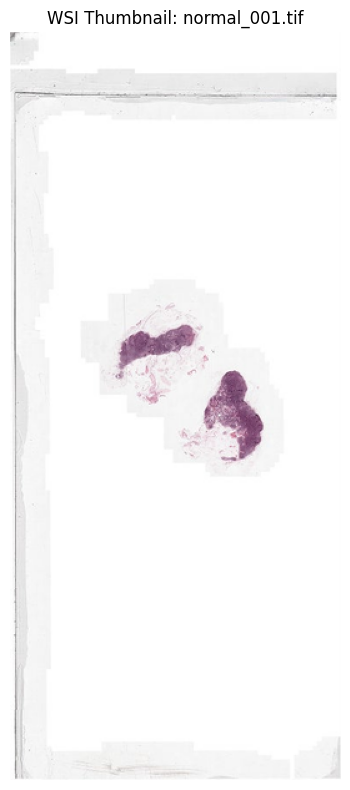


Slide size in GB: ~64.9 GB uncompressed


In [12]:
import openslide
from openslide import OpenSlide
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# Ensure cfg is defined (in case Cell 1 or Cell 2 wasn't run or kernel was restarted)
if 'cfg' not in locals():
    
    # Define DEVICE if not already defined
    if 'DEVICE' not in locals():
        import torch
        DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    class Config:
        PROJECT_ROOT    = Path('./').parent
        DATA_DIR        = Path('./data')
        PATCHES_DIR     = Path('./data/patches')
        FEATURES_DIR    = Path('./data/features')
        CHECKPOINTS_DIR = Path('./checkpoints')
        OUTPUTS_DIR     = Path('./outputs')
        CAMELYON16_DIR  = Path('./data/camelyon16')
        PATCH_SIZE      = 256
        MAGNIFICATION   = 20
        LEVEL           = 1
        BACKGROUND_THR  = 0.85
        KNN_K           = 8
        FEATURE_DIM     = 512
        VQC_INPUT_DIM   = 8
        N_QUBITS        = 3
        VQC_LAYERS      = 2
        GNN_HIDDEN      = 256
        BATCH_SIZE      = 4
        LR              = 1e-4
        EPOCHS          = 50
        SEED            = 42
        DEVICE          = DEVICE
    cfg = Config()
    for d in [cfg.DATA_DIR, cfg.PATCHES_DIR, cfg.FEATURES_DIR,
              cfg.CHECKPOINTS_DIR, cfg.OUTPUTS_DIR, cfg.CAMELYON16_DIR]:
        d.mkdir(parents=True, exist_ok=True)

# Find all slides in the CAMELYON16 directory structure
# Slides can be in subdirectories like tumor/, normal/, test/
slide_paths = []
slide_paths += list(cfg.CAMELYON16_DIR.glob('*.tif'))  # root level
slide_paths += list(cfg.CAMELYON16_DIR.glob('**/*.tif'))  # recursively in subdirectories
slide_paths += list(cfg.CAMELYON16_DIR.glob('**/*.svs'))
slide_paths += list(cfg.CAMELYON16_DIR.glob('**/*.ndpi'))

# Remove duplicates and mask files
slide_paths = list(set(p for p in slide_paths if 'mask' not in p.name.lower()))

if len(slide_paths) == 0:
    print('No slides found in:', cfg.CAMELYON16_DIR)
    print('Please download at least 1 CAMELYON16 slide.')
    print('Place it in:', cfg.CAMELYON16_DIR.resolve())
else:
    print(f'Found {len(slide_paths)} slides:')
    for p in sorted(slide_paths)[:10]:  # Show first 10
        print(f'  {p.name}')
    if len(slide_paths) > 10:
        print(f'  ... and {len(slide_paths) - 10} more')
    
    # Open first slide and explore
    slide_path = sorted(slide_paths)[0]
    slide = OpenSlide(str(slide_path))
    
    print(f'\nSlide: {slide_path.name}')
    print(f'Dimensions (level 0): {slide.dimensions[0]:,} x {slide.dimensions[1]:,} px')
    print(f'Number of levels:     {slide.level_count}')
    print(f'Level dimensions:')
    for lvl in range(slide.level_count):
        w, h = slide.level_dimensions[lvl]
        ds = slide.level_downsamples[lvl]
        print(f'  Level {lvl}: {w:,} x {h:,} px (downsample {ds:.1f}x)')
   
    # Show thumbnail of the whole slide
    thumb = slide.get_thumbnail((600, 600))
    
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.imshow(thumb)
    ax.set_title(f'WSI Thumbnail: {slide_path.name}', fontsize=12)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(str(cfg.OUTPUTS_DIR / 'wsi_thumbnail.png'), dpi=100, bbox_inches='tight')
    plt.show()
    print(f'\nSlide size in GB: ~{(slide.dimensions[0] * slide.dimensions[1] * 3) / 1e9:.1f} GB uncompressed')
    slide.close()

---
## Cell 6 — Tissue Detection (Otsu Thresholding)

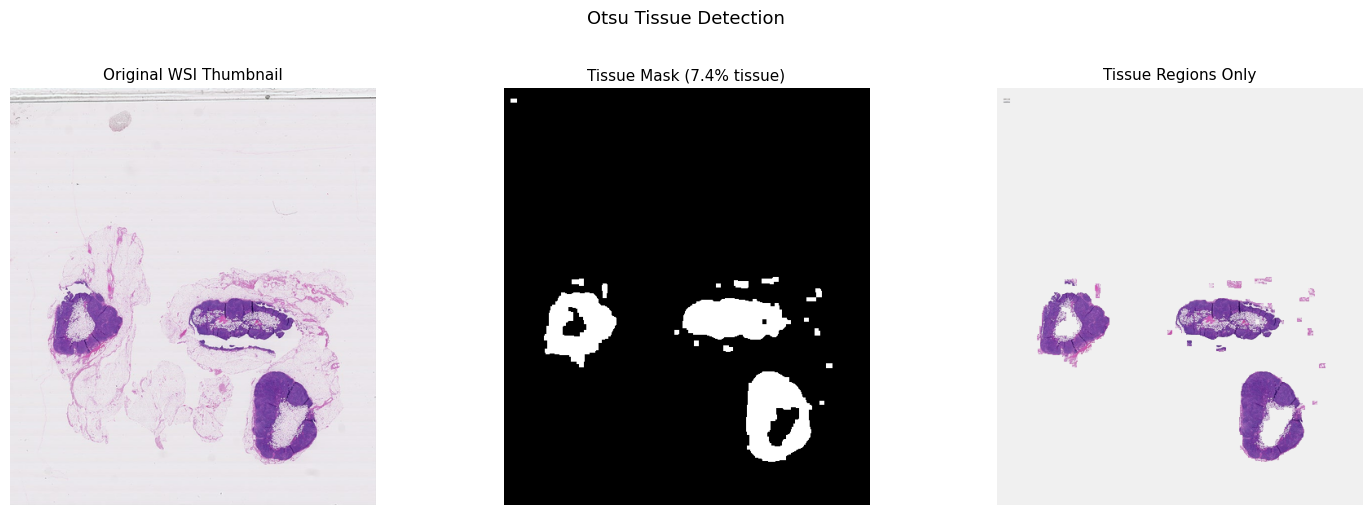

Tissue coverage: 7.4%


In [13]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

def get_tissue_mask(slide: OpenSlide, thumbnail_size: int = 512) -> np.ndarray:
    """
    Creates a binary tissue mask from a WSI thumbnail.
    Returns mask where 1 = tissue, 0 = background.
    
    How it works:
    1. Get a small thumbnail of the slide
    2. Convert to grayscale
    3. Apply Otsu thresholding — automatically finds the
       threshold that separates tissue (dark) from background (white)
    4. Morphological operations to clean up noise
    """
    # Get thumbnail at low resolution for speed
    thumb = slide.get_thumbnail((thumbnail_size, thumbnail_size))
    thumb_np = np.array(thumb.convert('RGB'))
    
    # Convert to grayscale
    gray = cv2.cvtColor(thumb_np, cv2.COLOR_RGB2GRAY)
    
    # Otsu thresholding — finds optimal threshold automatically
    # Tissue is darker than background, so we invert
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # Morphological closing — fills small holes in tissue regions
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    
    # Morphological opening — removes small noise patches
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    
    return mask.astype(bool), thumb_np


def is_tissue_patch(patch: np.ndarray, threshold: float = 0.85) -> bool:
    """
    Returns True if patch contains enough tissue (not mostly background).
    
    Background detection: white pixels (all channels > 220)
    Rejects patch if background_fraction > threshold.
    """
    # Count pixels where all RGB channels > 220 (white/background)
    is_white = np.all(patch > 220, axis=2)
    background_fraction = is_white.mean()
    return background_fraction < threshold


# Test on the first slide
if len(slide_paths) > 0:
    slide = OpenSlide(str(slide_paths[0]))
    mask, thumb_np = get_tissue_mask(slide)
    
    tissue_percent = (mask.sum() / mask.size) * 100
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(thumb_np)
    axes[0].set_title('Original WSI Thumbnail', fontsize=11)
    axes[0].axis('off')
    
    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title(f'Tissue Mask ({tissue_percent:.1f}% tissue)', fontsize=11)
    axes[1].axis('off')
    
    # Overlay mask on thumbnail
    overlay = thumb_np.copy()
    overlay[~mask] = [240, 240, 240]  # grey out background
    axes[2].imshow(overlay)
    axes[2].set_title('Tissue Regions Only', fontsize=11)
    axes[2].axis('off')
    
    plt.suptitle('Otsu Tissue Detection', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(str(cfg.OUTPUTS_DIR / 'tissue_mask.png'), dpi=100, bbox_inches='tight')
    plt.show()
    print(f'Tissue coverage: {tissue_percent:.1f}%')
    slide.close()
else:
    print('No slides loaded — skipping tissue detection demo.')
    print('This will work once you add CAMELYON16 slides.')

---
## Cell 7 — Patch Extractor (the core preprocessing function)

In [16]:
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from tqdm import tqdm
import json

def extract_patches_from_slide(
    slide_path: Path,
    patch_size: int = 256,
    level: int = 1,
    bg_threshold: float = 0.85,
    max_patches: int = None,
    verbose: bool = True
) -> tuple:
    """
    Extracts tissue patches from a whole slide image.
    
    Args:
        slide_path:    Path to the .tif / .svs / .ndpi slide file
        patch_size:    Size of each square patch in pixels
        level:         Pyramid level (0=highest res, 1=half res)
        bg_threshold:  Reject patch if background > this fraction
        max_patches:   Cap total patches (None = no limit)
        verbose:       Print progress
    
    Returns:
        patches:       List of PIL Images
        coords:        List of (x, y) patch grid coordinates
        slide_id:      Slide filename without extension
    """
    slide = OpenSlide(str(slide_path))
    slide_id = slide_path.stem
    
    # Get dimensions at the chosen level
    w, h = slide.level_dimensions[level]
    downsample = slide.level_downsamples[level]
    
    if verbose:
        n_cols = w // patch_size
        n_rows = h // patch_size
        print(f'  Slide: {slide_id}')
        print(f'  Level {level} size: {w}x{h} px')
        print(f'  Grid: {n_cols} cols x {n_rows} rows = {n_cols*n_rows:,} total positions')
    
    patches = []
    coords  = []
    
    col_idx = 0
    for x in range(0, w - patch_size, patch_size):
        for y in range(0, h - patch_size, patch_size):
            # Convert level-1 coordinates to level-0 for read_region
            x0 = int(x * downsample)
            y0 = int(y * downsample)
            
            # Read patch from slide at specified level
            patch = slide.read_region(
                location=(x0, y0),
                level=level,
                size=(patch_size, patch_size)
            ).convert('RGB')  # Convert RGBA → RGB
            
            patch_np = np.array(patch)
            
            # Filter background patches
            if is_tissue_patch(patch_np, threshold=bg_threshold):
                patches.append(patch)
                coords.append((col_idx, y // patch_size))  # grid coords
                
                if max_patches and len(patches) >= max_patches:
                    slide.close()
                    if verbose:
                        print(f'  Extracted {len(patches)} patches (capped at {max_patches})')
                    return patches, coords, slide_id
        col_idx += 1
    
    slide.close()
    if verbose:
        print(f'  Extracted {len(patches):,} tissue patches (rejected {((n_cols*n_rows - len(patches))/(n_cols*n_rows)*100):.1f}% background)')
    
    return patches, coords, slide_id


print('Patch extractor function defined.')
print('Ready to run on CAMELYON16 slides.')

Patch extractor function defined.
Ready to run on CAMELYON16 slides.


---
## Cell 8 — Stain Normalisation (Macenko Method)

Loading PatchCamelyon...
Loaded: 235,929 train samples
Testing stain normalisation on PatchCamelyon samples...


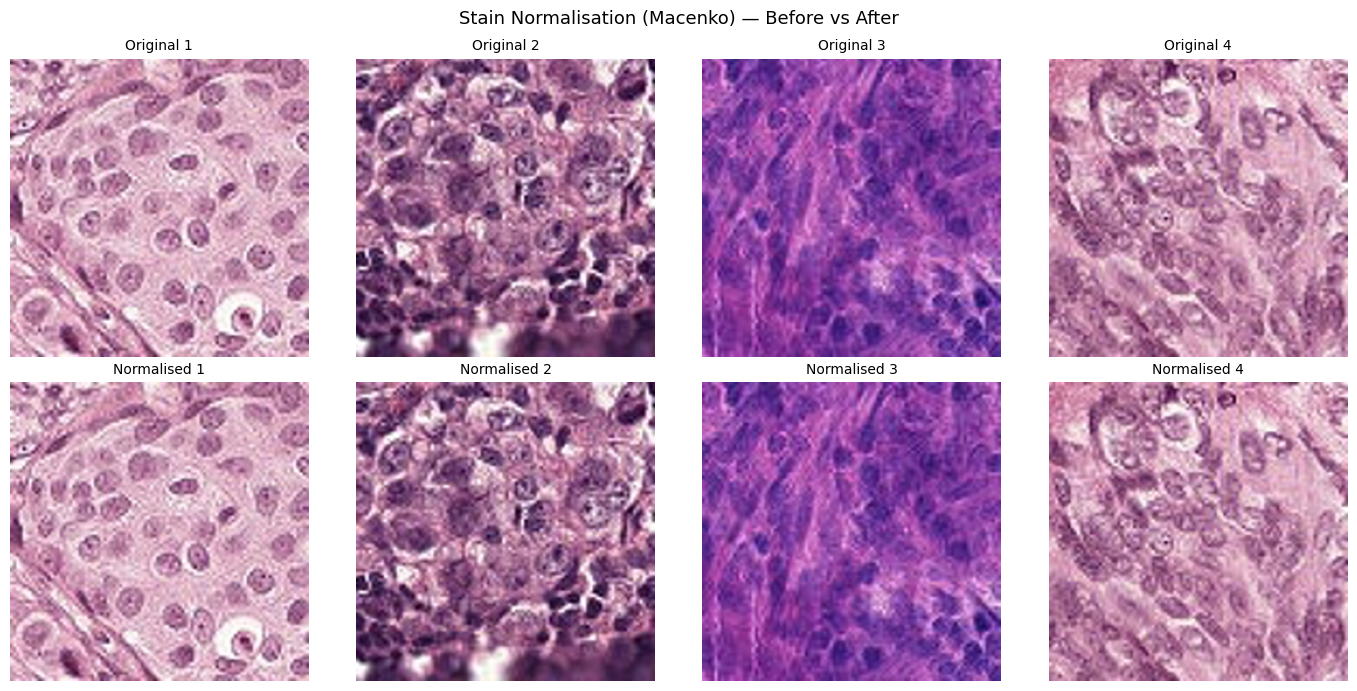

Stain normalisation working correctly.


In [30]:
import torchstain
from torchstain import normalizers
from torchvision import transforms
from PIL import Image
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Ensure pcam is loaded (in case Cell 4 wasn't run)
if 'pcam' not in locals():
    print('Loading PatchCamelyon...')
    from datasets import load_dataset
    pcam = load_dataset('1aurent/PatchCamelyon')
    train_val = pcam['train'].train_test_split(test_size=0.1, seed=42)
    pcam['train'] = train_val['train']
    pcam['validation'] = train_val['test']
    print(f'Loaded: {len(pcam["train"]):,} train samples')

def build_stain_normaliser(reference_patch: Image.Image) -> tuple:
    """
    Build a Macenko stain normaliser fitted to a reference patch.
    
    The normaliser maps all future patches to match the stain
    distribution of this reference, reducing cross-hospital variability.
    
    Best practice: use a patch from the centre of a tissue-rich slide
    as your reference. It should have clear H (purple) and E (pink) staining.
    """
    T = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x * 255)  # Macenko expects 0-255 range
    ])
    
    normaliser = normalizers.MacenkoNormalizer(backend='torch')
    
    # Fit the normaliser to the reference patch
    ref_tensor = T(reference_patch).unsqueeze(0)
    try:
        normaliser.fit(ref_tensor)
        print('Stain normaliser fitted to reference patch.')
    except Exception as e:
        print(f'Warning: normaliser fit failed ({e}) — using default parameters')
    
    return normaliser, T


def normalise_patch(patch: Image.Image, normaliser,
                    T: transforms.Compose) -> Image.Image:
    """
    Applies Macenko stain normalisation to a single patch.
    Returns normalised PIL Image.
    """
    try:
        patch_tensor = T(patch).unsqueeze(0)
        norm_tensor = normaliser.normalize(I=patch_tensor)
        # Convert back to PIL
        norm_np = norm_tensor.squeeze(0).permute(1, 2, 0).numpy()
        norm_np = np.clip(norm_np, 0, 255).astype(np.uint8)
        return Image.fromarray(norm_np)
    except Exception:
        # If normalisation fails (very bright/dark patches), return original
        return patch


# Demo with PatchCamelyon samples (since you may not have CAMELYON16 yet)
print('Testing stain normalisation on PatchCamelyon samples...')

# Get a tumour patch as reference
raw_transform = transforms.Compose([transforms.Resize((256, 256))])

# Get some samples from PatchCamelyon
tumour_idx = next(i for i, s in enumerate(pcam['train']) if s['label'] == 1)
reference_pil = pcam['train'][tumour_idx]['image']
reference_pil = reference_pil.resize((256, 256))

normaliser, T_stain = build_stain_normaliser(reference_pil)

# Show before/after on 4 patches
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Stain Normalisation (Macenko) — Before vs After', fontsize=13)

sample_indices = [i * 500 for i in range(4)]
for j, idx in enumerate(sample_indices):
    orig = pcam['train'][idx]['image'].resize((256, 256))
    norm = normalise_patch(orig, normaliser, T_stain)
    
    axes[0][j].imshow(orig)
    axes[0][j].set_title(f'Original {j+1}', fontsize=10)
    axes[0][j].axis('off')
    
    axes[1][j].imshow(norm)
    axes[1][j].set_title(f'Normalised {j+1}', fontsize=10)
    axes[1][j].axis('off')

plt.tight_layout()
plt.savefig(str(cfg.OUTPUTS_DIR / 'stain_normalisation.png'), dpi=100, bbox_inches='tight')
plt.show()
print('Stain normalisation working correctly.')

---
## Cell 9 — Full WSI Preprocessing Pipeline
Combines everything: extract → filter → normalise → save

In [33]:
import pickle
from tqdm import tqdm
from torchstain import normalizers

def preprocess_slide(
    slide_path: Path,
    output_dir: Path,
    normaliser,
    T_stain,
    cfg,
    max_patches: int = None
) -> dict:
    """
    Full preprocessing pipeline for one WSI slide.
    
    1. Extract tissue patches (Otsu filtered)
    2. Apply Macenko stain normalisation
    3. Save patches as a .pkl file with metadata
    
    Returns dict with slide metadata.
    """
    # Ensure output directory exists
    output_dir.mkdir(parents=True, exist_ok=True)
    
    slide_id = slide_path.stem
    save_path = output_dir / f'{slide_id}.pkl'
    
    # Skip if already processed
    if save_path.exists():
        print(f'  {slide_id}: already processed, skipping')
        with open(save_path, 'rb') as f:
            data = pickle.load(f)
        return {'slide_id': slide_id, 'n_patches': len(data['coords']), 'skipped': True}
    
    # Step 1: Extract patches
    patches, coords, slide_id = extract_patches_from_slide(
        slide_path=slide_path,
        patch_size=cfg.PATCH_SIZE,
        level=cfg.LEVEL,
        bg_threshold=cfg.BACKGROUND_THR,
        max_patches=max_patches,
        verbose=True
    )
    
    if len(patches) == 0:
        print(f'  WARNING: No tissue patches found in {slide_id}')
        return {'slide_id': slide_id, 'n_patches': 0, 'error': 'no tissue'}
    
    # Step 2: Stain normalisation
    normalised_patches = []
    for patch in patches:
        norm = normalise_patch(patch, normaliser, T_stain)
        normalised_patches.append(norm)
    
    # Step 3: Save
    data = {
        'slide_id': slide_id,
        'patches': normalised_patches,   # list of PIL Images
        'coords': coords,                # list of (col, row) grid positions
        'n_patches': len(normalised_patches),
        'patch_size': cfg.PATCH_SIZE,
        'level': cfg.LEVEL,
    }
    
    with open(save_path, 'wb') as f:
        pickle.dump(data, f, protocol=4)
    
    print(f'  Saved: {save_path.name} ({len(normalised_patches)} patches)')
    return {'slide_id': slide_id, 'n_patches': len(normalised_patches)}


# Run on available slides
print('Starting WSI preprocessing pipeline...')
print('='*60)

results = []
if len(slide_paths) > 0:
    for slide_path in tqdm(slide_paths, desc='Processing slides'):
        try:
            result = preprocess_slide(
                slide_path=slide_path,
                output_dir=cfg.PATCHES_DIR,
                normaliser=normaliser,
                T_stain=T_stain,
                cfg=cfg,
                max_patches=3000  # cap per slide for prototyping
            )
            results.append(result)
        except Exception as e:
            print(f'  ERROR processing {slide_path.name}: {e}')
    
    print('\nPreprocessing Summary:')
    total_patches = sum(r.get('n_patches', 0) for r in results)
    print(f'  Slides processed: {len(results)}')
    print(f'  Total patches:    {total_patches:,}')
    print(f'  Saved to:         {cfg.PATCHES_DIR.resolve()}')
else:
    print('No CAMELYON16 slides found.')
    print('Add slides to:', cfg.CAMELYON16_DIR.resolve())
    print('The pipeline is ready — it will run automatically once slides are downloaded.')

Starting WSI preprocessing pipeline...


Processing slides:   0%|          | 0/220 [00:00<?, ?it/s]

  Slide: tumor_098
  Level 1 size: 47104x53760 px
  Grid: 184 cols x 210 rows = 38,640 total positions
  Extracted 3000 patches (capped at 3000)


Processing slides:   0%|          | 1/220 [00:24<1:27:46, 24.05s/it]

  Saved: tumor_098.pkl (3000 patches)
  Slide: normal_076
  Level 1 size: 48896x110336 px
  Grid: 191 cols x 431 rows = 82,321 total positions
  Extracted 3000 patches (capped at 3000)


...

  Saved: tumor_032.pkl (3000 patches)
  Slide: normal_021
  Level 1 size: 48896x108544 px
  Grid: 191 cols x 424 rows = 80,984 total positions
  Extracted 2,320 tissue patches (rejected 97.1% background)


Processing slides: 100%|█████████▉| 219/220 [3:17:40<01:15, 75.76s/it]

  Saved: normal_021.pkl (2320 patches)
  Slide: tumor_025
  Level 1 size: 48896x109312 px
  Grid: 191 cols x 427 rows = 81,557 total positions
  Extracted 3000 patches (capped at 3000)


Processing slides: 100%|██████████| 220/220 [3:18:45<00:00, 54.20s/it]

  Saved: tumor_025.pkl (3000 patches)

Preprocessing Summary:
  Slides processed: 220
  Total patches:    652,152
  Saved to:         /home/kabilash/PATHQ--Quantum-Digital-Pathology-for-Whole-Slide-Image-Analysis-DMI-/notebooks/data/patches


---
## Cell 10 — PatchCamelyon PyTorch Dataset (for Week 3 training)

In [34]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class PatchCamelyonDataset(Dataset):
    """
    PyTorch Dataset for PatchCamelyon.
    Used for prototyping the full PATHQ pipeline before moving to WSI scale.
    """
    
    def __init__(self, hf_dataset, split: str = 'train', patch_size: int = 96):
        """
        Args:
            hf_dataset:  HuggingFace dataset object from load_dataset()
            split:       'train', 'validation', or 'test'
            patch_size:  Resize patches to this size (default 96, or 256 for consistency with WSI)
        """
        self.data = hf_dataset[split]
        self.transform = transforms.Compose([
            transforms.Resize((patch_size, patch_size)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.7019, 0.5462, 0.6869],  # H&E tissue mean
                std=[0.2347, 0.2785, 0.2128]     # H&E tissue std
            )
        ])
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        sample = self.data[idx]
        image  = self.transform(sample['image'])
        label  = torch.tensor(sample['label'], dtype=torch.long)
        return image, label


# Build datasets and dataloaders
train_dataset = PatchCamelyonDataset(pcam, 'train', patch_size=96)
val_dataset   = PatchCamelyonDataset(pcam, 'validation', patch_size=96)
test_dataset  = PatchCamelyonDataset(pcam, 'test', patch_size=96)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

print(f'PatchCamelyon DataLoaders ready:')
print(f'  Train:  {len(train_dataset):,} samples, {len(train_loader):,} batches')
print(f'  Val:    {len(val_dataset):,} samples,   {len(val_loader):,} batches')
print(f'  Test:   {len(test_dataset):,} samples,   {len(test_loader):,} batches')

# Verify one batch
images, labels = next(iter(train_loader))
print(f'\nBatch shape:  {images.shape}   (B, C, H, W)')
print(f'Label shape:  {labels.shape}')
print(f'Label counts: {labels.sum().item()} tumour, {(1-labels).sum().item()} normal in this batch')
print(f'Pixel range:  [{images.min():.2f}, {images.max():.2f}]')

PatchCamelyon DataLoaders ready:
  Train:  235,929 samples, 3,687 batches
  Val:    26,215 samples,   410 batches
  Test:   32,768 samples,   512 batches

Batch shape:  torch.Size([64, 3, 96, 96])   (B, C, H, W)
Label shape:  torch.Size([64])
Label counts: 36 tumour, 28 normal in this batch
Pixel range:  [-3.23, 1.63]


---
## Cell 11 — Sanity Check: Everything works end to end

In [36]:
import pennylane as qml

print('PATHQ WEEK 1 SANITY CHECK')
print('='*60)

# 1. PyTorch GPU
x = torch.randn(4, 3, 96, 96).to(DEVICE)
print(f'[OK] PyTorch tensor on {DEVICE}: {x.shape}')

# 2. PatchCamelyon dataloader
imgs, lbls = next(iter(train_loader))
print(f'[OK] PatchCamelyon batch: {imgs.shape}, labels: {lbls.shape}')

# 3. PathMNIST loaded
if 'path_train' not in locals():
    from medmnist import PathMNIST
    import torchvision.transforms as T
    transform = T.Compose([
        T.ToTensor(),
        T.Normalize(mean=[.5], std=[.5])
    ])
    path_train = PathMNIST(split='train', transform=transform,
                            download=True, root=str(cfg.DATA_DIR))

img, lbl = path_train[0]
print(f'[OK] PathMNIST sample: {img.shape}, class {lbl[0]}')

# 4. PennyLane quantum circuit
dev = qml.device('default.qubit', wires=3)

@qml.qnode(dev)
def test_circuit(x):
    # Amplitude encoding: encode 8-dim normalised vector into 3-qubit state
    qml.AmplitudeEmbedding(x, wires=[0, 1, 2], normalize=True)
    # Apply a basic rotation gate
    qml.RY(0.5, wires=0)
    qml.CNOT(wires=[0, 1])
    # Measure expectation values
    return [qml.expval(qml.PauliZ(i)) for i in range(3)]

test_input = np.random.randn(8)
test_input = test_input / np.linalg.norm(test_input)  # normalise to unit norm
result = test_circuit(test_input)
print(f'[OK] PennyLane VQC: input {test_input.shape} → output {len(result)} expectation values')
print(f'     Qubit measurements: Z0={result[0]:.3f}, Z1={result[1]:.3f}, Z2={result[2]:.3f}')

# 5. Stain normaliser
sample_img = pcam['train'][0]['image'].resize((256, 256))
normalised = normalise_patch(sample_img, normaliser, T_stain)
print(f'[OK] Stain normalisation: {np.array(sample_img).shape} → {np.array(normalised).shape}')

# 6. Check outputs directory
saved_figs = list(cfg.OUTPUTS_DIR.glob('*.png'))
print(f'[OK] Output figures saved: {len(saved_figs)} files')

print()
print('='*60)
print('WEEK 1 COMPLETE!')
print()
print('Next steps:')
print('  1. Download CAMELYON16 slides if not done yet')
print('     → camelyon16.grand-challenge.org (free registration)')
print('  2. Place slides in:', cfg.CAMELYON16_DIR.resolve())
print('  3. Re-run Cells 5, 9 to process them')
print('  4. Open week2_feature_extraction.ipynb')
print()
print('Your environment is fully ready for PATHQ.')

PATHQ WEEK 1 SANITY CHECK
[OK] PyTorch tensor on cuda: torch.Size([4, 3, 96, 96])
[OK] PatchCamelyon batch: torch.Size([64, 3, 96, 96]), labels: torch.Size([64])


100%|██████████| 206M/206M [01:29<00:00, 2.30MB/s] 


[OK] PathMNIST sample: torch.Size([3, 28, 28]), class 0
[OK] PennyLane VQC: input (8,) → output 3 expectation values
     Qubit measurements: Z0=0.210, Z1=-0.347, Z2=0.071
[OK] Stain normalisation: (256, 256, 3) → (256, 256, 3)
[OK] Output figures saved: 5 files

WEEK 1 COMPLETE!

Next steps:
  1. Download CAMELYON16 slides if not done yet
     → camelyon16.grand-challenge.org (free registration)
  2. Place slides in: /home/kabilash/PATHQ--Quantum-Digital-Pathology-for-Whole-Slide-Image-Analysis-DMI-/notebooks/data/camelyon16
  3. Re-run Cells 5, 9 to process them
  4. Open week2_feature_extraction.ipynb

Your environment is fully ready for PATHQ.


---
## Cell 12 — Quick PennyLane Intro (run this to understand qubits)

This is a mini-lesson on quantum circuits. Run it to build intuition before Week 4.

In [37]:
import pennylane as qml
import numpy as np

# ── LESSON: What does a quantum circuit look like? ─────────────────────────
print('QUANTUM CIRCUIT MINI-LESSON')
print('='*50)

# Create a 3-qubit simulator device
dev = qml.device('default.qubit', wires=3)

@qml.qnode(dev)
def lesson_circuit(theta):
    """
    A simple VQC-style circuit.
    
    RY(theta) rotates qubit on Y-axis of Bloch sphere.
    CNOT entangles two qubits.
    PauliZ measurement returns +1 (qubit=|0>) or -1 (qubit=|1>).
    """
    # Layer 1: single-qubit rotations
    qml.RY(theta[0], wires=0)
    qml.RY(theta[1], wires=1)
    qml.RY(theta[2], wires=2)
    
    # Entanglement layer
    qml.CNOT(wires=[0, 1])
    qml.CNOT(wires=[1, 2])
    
    # Layer 2: more rotations
    qml.RZ(theta[3], wires=0)
    qml.RZ(theta[4], wires=1)
    qml.RZ(theta[5], wires=2)
    
    # Measure all 3 qubits → 3 expectation values
    return [qml.expval(qml.PauliZ(i)) for i in range(3)]

# Draw the circuit
theta_example = np.array([0.1, 0.5, 1.2, 0.3, 0.8, 0.4])
print('\nCircuit diagram:')
print(qml.draw(lesson_circuit)(theta_example))

# Run with different theta values and see outputs change
print('\nOutput vs theta[0] (RY rotation on qubit 0):')
print(f'{"theta[0]":>10}  {"Z0":>8}  {"Z1":>8}  {"Z2":>8}')
print('-' * 42)
for t in [0.0, 0.5, 1.0, 1.5, np.pi/2, np.pi]:
    theta_test = np.array([t, 0.5, 1.2, 0.3, 0.8, 0.4])
    out = lesson_circuit(theta_test)
    print(f'{t:>10.3f}  {float(out[0]):>8.3f}  {float(out[1]):>8.3f}  {float(out[2]):>8.3f}')

print()
print('Key insight: theta=0 → Z0=+1 (qubit in |0> state)')
print('             theta=pi → Z0=-1 (qubit in |1> state)')
print('             theta=pi/2 → Z0~0 (superposition!)')
print()
print('This is what your VQC encoder does with patch features.')
print('Different features → different theta → different qubit states.')
print('Tumour patches and normal patches will explore different')
print('regions of quantum state space — that is the PATHQ XAI signal.')

QUANTUM CIRCUIT MINI-LESSON

Circuit diagram:
0: ──RY(0.10)─╭●──RZ(0.30)───────────┤  <Z>
1: ──RY(0.50)─╰X─╭●─────────RZ(0.80)─┤  <Z>
2: ──RY(1.20)────╰X─────────RZ(0.40)─┤  <Z>

Output vs theta[0] (RY rotation on qubit 0):
  theta[0]        Z0        Z1        Z2
------------------------------------------
     0.000     1.000     0.878     0.318
     0.500     0.878     0.770     0.279
     1.000     0.540     0.474     0.172
     1.500     0.071     0.062     0.022
     1.571     0.000     0.000     0.000
     3.142    -1.000    -0.878    -0.318

Key insight: theta=0 → Z0=+1 (qubit in |0> state)
             theta=pi → Z0=-1 (qubit in |1> state)
             theta=pi/2 → Z0~0 (superposition!)

This is what your VQC encoder does with patch features.
Different features → different theta → different qubit states.
Tumour patches and normal patches will explore different
regions of quantum state space — that is the PATHQ XAI signal.
